In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from collections import defaultdict


from eelbrain import NDVar, UTS, Sensor, Case, Var, Factor, Dataset, save, plot, boosting

from ridge_regression_functions import (
    load_all_trials,
    normalise_eeg,
    split_trials_by_condition,
    WIN_OFFSET1,
    WIN_OFFSET2,
)

# 10 ms sampling → 100 Hz
SAMPLE_RATE = 100.0
TSTEP = 1.0 / SAMPLE_RATE  # 0.01 s

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

from pathlib import Path
import numpy as np
from eelbrain import boosting, save

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
NOT_EVAL_SUBS = [35, 46, 60, 68, 97]  # subjects not evaluated due to too few trials


# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow")

#PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_processed_clara")
#EEG_ROOT    = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2")


# Where to save TRFs and datasets
TRF_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran01\TRF")
DS_DIR  = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran01\datasets")

TRF_DIR.mkdir(parents=True, exist_ok=True)
DS_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Helper: number of trials in a dataset
# ---------------------------------------------------------------------
def n_trials(ds):
    if ds is None:
        return 0
    return ds['eeg'].x.shape[0]  # case × sensor × time


# ---------------------------------------------------------------------
# TRF parameters (change if you like)
# ---------------------------------------------------------------------
TMIN = -3   # seconds
TMAX =  3
BASIS = 0.5  # 500 ms
PARTITIONS = 4


In [2]:

def make_subject_datasets_by_load(sub: int, eeg_root: Path, pupil_root: Path):
    """
    Return a dict: {load_value: Dataset} for this subject.
    Each Dataset has:
      - 'eeg': NDVar(case × sensor × time)
      - 'ppd': NDVar(case × time)
      - 'epoch': Factor (trial IDs)
      - 'load': Var (all same value inside each Dataset)
    Only 'memory' trials are fvused.
    """
    trials = load_all_trials(sub, eeg_root, pupil_root)
    mem_trials, _ = split_trials_by_condition(
        trials,
        memory_label="memory",
        control_label="control",
    )

    if not mem_trials:
        print(f"sub-{sub:03d}: no memory trials")
        return {}

    # 1) group memory trials by load
    by_load = defaultdict(list)
    for eeg, pupil, meta in mem_trials:
        load_val = meta.get("load", None)
        if load_val is None:
            continue
        by_load[load_val].append((eeg, pupil, meta))

    ds_by_load = {}

    # 2) build one Dataset per load
    for load_val, trials_this_load in by_load.items():
        trimmed = []
        lengths = []

        # 2a) trim using WIN_OFFSET1/2 like your other code
        for eeg, pupil, meta in trials_this_load:
            if eeg.ndim == 1:
                eeg = eeg[:, None]
            if pupil.ndim == 2 and pupil.shape[1] == 1:
                pupil = pupil[:, 0]
            elif pupil.ndim != 1:
                pupil = pupil.reshape(-1)

            T = min(len(eeg), len(pupil))
            if T == 0:
                continue

            start = WIN_OFFSET1
            stop  = T - WIN_OFFSET2
            if stop <= start:
                continue

            eeg_w   = eeg[start:stop, :]
            pupil_w = pupil[start:stop]
            Tw = len(eeg_w)
            if Tw == 0:
                continue

            trimmed.append((eeg_w, pupil_w, meta))
            lengths.append(Tw)

        if not trimmed:
            print(f"sub-{sub:03d}, load {load_val}: no usable trials after trimming")
            continue

        # 2b) crop to shortest trial *within this load only*
        L = min(lengths)
        n_trials = len(trimmed)
        n_channels = trimmed[0][0].shape[1]

        eeg_data = np.zeros((n_trials, n_channels, L), float)
        ppd_data = np.zeros((n_trials, L), float)
        epochs = []

        for i, (eeg_w, pupil_w, meta) in enumerate(trimmed):
            eeg_crop   = eeg_w[:L, :]
            pupil_crop = pupil_w[:L]

            eeg_norm = normalise_eeg(eeg_crop) 

            # z-score pupil per trial
            m = pupil_crop.mean()
            s = pupil_crop.std(ddof=0)
            pupil_z = (pupil_crop - m) / (s if s > 0 else 1.0)

            eeg_data[i, :, :] = eeg_norm.T   # (C, L)
            ppd_data[i, :]    = pupil_z      # (L,)
            epochs.append(str(meta.get("epoch", f"{i}")))

        time = UTS(tmin=0.0, tstep=TSTEP, nsamples=L)
        case = Case(n_trials)
        sensor17 = Sensor.from_montage('standard_1020', channels=FRONTAL_MIDLINE)

        eeg_nd = NDVar(eeg_data, (case, sensor17, time), name='eeg')
        ppd_nd = NDVar(ppd_data, (case, time), name='ppd')

        ds = Dataset({
            'eeg': eeg_nd,
            'ppd': ppd_nd,
            'epoch': Factor(epochs),
            'load': Var(np.full(n_trials, load_val, int)),
        })
        ds.info['subject'] = f"sub-{sub:03d}"
        ds_by_load[load_val] = ds

    return ds_by_load


In [6]:
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow")

ds_by_load_42 = make_subject_datasets_by_load(42, EEG_ROOT, PUPIL_ROOT)

ds_5   = ds_by_load_42.get(5)
ds_9   = ds_by_load_42.get(9)
ds_13  = ds_by_load_42.get(13)


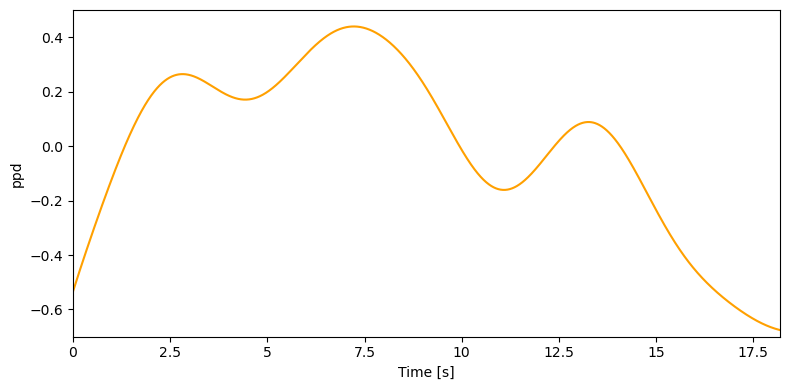

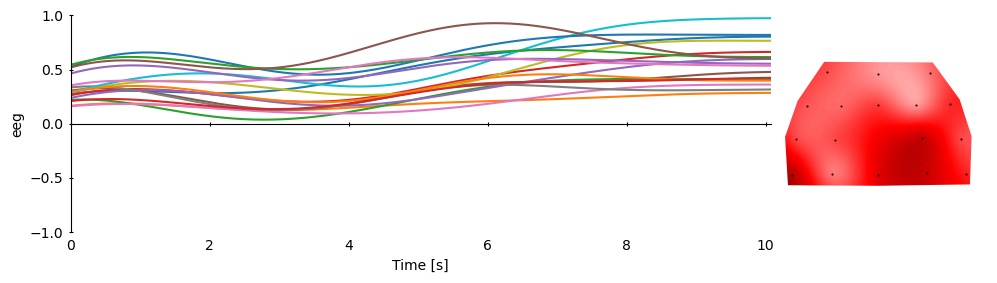

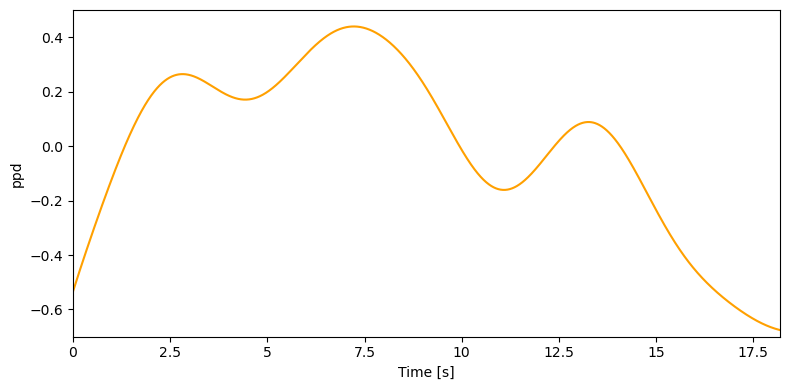

In [ ]:
plot.TopoButterfly('eeg', data=ds_5, frame='t')  # quick sanity check
plot.UTS('ppd', data=ds_9)                       # pupil time courses

In [ ]:
tmin = -1.5
tmax =  1.5

# Example: encoding ppd → EEG for load 13
enc_s42_13 = boosting(
    y='eeg',
    x='ppd',
    tstart=tmin,
    tstop=tmax,
    data=ds_13,
    basis=0.25,
    basis_window='hamming',
    partitions=4,
    test=True,
)

# decoding EEG → ppd for load 13
dec_s42_13 = boosting(
    y='ppd',
    x='eeg',
    tstart=tmin,
    tstop=tmax,
    data=ds_13,
    basis=0.25,
    basis_window='hamming',
    partitions=4,
    test=True,
)
save.pickle(enc_s42_13, f"TRF/enc_ppd_to_eeg_sub-042_l13.pickle")
save.pickle(dec_s42_13, f"TRF/dec_eeg_to_ppd_sub-042_l13.pickle")

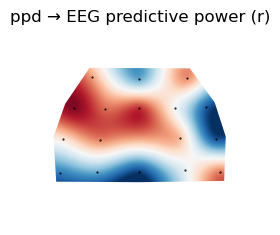

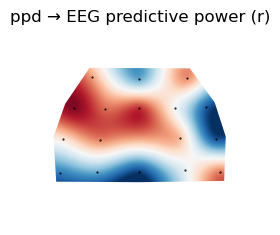

In [ ]:
from eelbrain import plot

# TRF for all channels
#plot.UTS(enc_s42_13.h_scaled, xax='time')

# Predictive power topography (will be a 17-sensor "topomap" based on our dummy Sensor layout)
plot.Topomap(enc_s42_13.r, axtitle='ppd → EEG predictive power (r)')

In [ ]:
print("Decoding r:", dec_s42_13.r)


Decoding r: 0.05359434976795545


In [3]:
DECODING_ONLY = True
SUBJECTS = np.setdiff1d(np.arange(34, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
for subj in SUBJECTS:
    if subj in NOT_EVAL_SUBS:
        continue
    print(f"\n========== Subject {subj:03d} ==========")

    # build datasets per load for this subject
    ds_by_load = make_subject_datasets_by_load(subj, EEG_ROOT, PUPIL_ROOT)

    if not ds_by_load:
        print("  No memory datasets for this subject; skipping.")
        continue

    ds_5   = ds_by_load.get(5)
    ds_9   = ds_by_load.get(9)
    ds_13  = ds_by_load.get(13)

    n5  = n_trials(ds_5)
    n9  = n_trials(ds_9)
    n13 = n_trials(ds_13)

    print(f"  Trials per load: 5 → {n5}, 9 → {n9}, 13 → {n13}")

    # -----------------------------------------------------------------
    # Choose which dataset to use, following your rules:
    #   - default: load 13
    #   - if n9 >= 1.33 * n13 and ds_9 exists → use load 9
    #   - else if n5 >= 2.0 * n13 and ds_5 exists → use load 5
    #   - print whenever we do NOT take load 13
    # -----------------------------------------------------------------
    chosen_load = 13
    chosen_ds   = ds_13

    # handle rare case: no load-13 dataset
    if n13 == 0:
        # fall back to the load with the most trials
        candidates = [(5, n5, ds_5), (9, n9, ds_9)]
        candidates = [(l, n, ds) for (l, n, ds) in candidates if n > 0]
        if not candidates:
            print("  No usable datasets for any load; skipping subject.")
            continue
        chosen_load, _, chosen_ds = max(candidates, key=lambda t: t[1])
        print(f"  No load-13 dataset; using load {chosen_load} (max trials).")
    else:
        # load 13 exists; apply your decision rules
        if ds_9 is not None and n9 >= 1.33 * n13:
            chosen_load = 9
            chosen_ds   = ds_9
            print(f"  Using load 9: n9 ({n9}) >= 1.33 * n13 ({n13:.1f})")
        elif ds_5 is not None and n5 >= 2.0 * n13:
            chosen_load = 5
            chosen_ds   = ds_5
            print(f"  Using load 5: n5 ({n5}) >= 2.0 * n13 ({n13:.1f})")
        else:
            # keep load 13; nothing to print extra (this is the default)
            pass


    # safety check
    if chosen_ds is None:
        print("  Chosen dataset is None; skipping subject.")
        continue

    print(f"  Final choice for subject {subj:03d}: load {chosen_load}, {n_trials(chosen_ds)} trials")

    # -----------------------------------------------------------------
    # Run encoder (ppd → EEG) and decoder (EEG → ppd)
    # -----------------------------------------------------------------
    print("  Fitting encoder (ppd → EEG)...")
    if not DECODING_ONLY:
        enc = boosting(
            y='eeg',
            x='ppd',
            tstart=TMIN,
            tstop=TMAX,
            data=chosen_ds,
            basis=BASIS,
            basis_window='hamming',
            partitions=PARTITIONS,
            test=1,
            #selective_stopping=True,
        )

    print("  Fitting decoder (EEG → ppd)...")
    dec = boosting(
        y='ppd',
        x='eeg',
        tstart=TMIN,
        tstop=TMAX,
        data=chosen_ds,
        basis=BASIS, #TODO make it bigger for SLOW component
        basis_window='hamming',
        partitions=PARTITIONS,
        test=1,
        selective_stopping=True,
    )

    # -----------------------------------------------------------------
    # Print decoder r
    # -----------------------------------------------------------------
    try:
        dec_r = float(dec.r)  # for scalar r; works if r is 0D NDVar too
    except Exception:
        # fallback if dec.r is something weird
        dec_r = np.asarray(dec.r.x).item()

    print(f"  Decoder r (EEG → ppd, load {chosen_load}): {dec_r:.4f}")

    # -----------------------------------------------------------------
    # Save encoder, decoder, and dataset
    # -----------------------------------------------------------------
    base = f"sub-{subj:03d}_l{chosen_load}"

    enc_path = TRF_DIR / f"enc_ppd_to_eeg_{base}.pickle"
    dec_path = TRF_DIR / f"dec_eeg_to_ppd_{base}.pickle"
    ds_path  = DS_DIR  / f"ds_{base}.pickle"

    if not DECODING_ONLY:
        save.pickle(enc, enc_path)
    save.pickle(dec, dec_path)
    save.pickle(chosen_ds, ds_path)

    if not DECODING_ONLY:
        print(f"  Saved encoder to {enc_path}")
    print(f"  Saved decoder to {dec_path}")
    print(f"  Saved dataset to {ds_path}")



========== Subject 034 ==========
  Trials per load: 5 → 35, 9 → 30, 13 → 32
  Final choice for subject 034: load 13, 32 trials
  Fitting encoder (ppd → EEG)...
  Fitting decoder (EEG → ppd)...
  Decoder r (EEG → ppd, load 13): 0.2631
  Saved decoder to C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran01\TRF\dec_eeg_to_ppd_sub-034_l13.pickle
  Saved dataset to C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran01\datasets\ds_sub-034_l13.pickle

========== Subject 036 ==========
  Trials per load: 5 → 14, 9 → 13, 13 → 16
  Final choice for subject 036: load 13, 16 trials
  Fitting encoder (ppd → EEG)...
  Fitting decoder (EEG → ppd)...
  Decoder r (EEG → ppd, load 13): 0.0962
  Saved decoder to C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran01\TRF\dec_eeg_to_ppd_sub-036_l13.pickle
  Saved dataset to C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran01\datasets\